Submit your answers to gradescope before or at the latest at 12:50pm.

In [1]:
using Plots

In [2]:
using SymPy

In [3]:
using JuMP
using GLPK

In [4]:
using NLsolve

# Question 1

It costs \$100 to produce an item.  If the production misses
the target of 20 with a deviation of 3 or more,
then the item must be discarded.

1. Define the quality loss function.

2. Compute the expected loss for the current production mean of 19
   and deviation 2.
        
3. Suppose we want to reduce the deviation of the production to 1.

   How much extra cost may this reduction add?

## answer to question 1

1. If the item misses the target of 20 by 3, the loss is 100 in both directions (17 and 23).  Let m=20, which is the target value for production and y is the value of the product.  The quality loss function is :
$$
L(y) = k(y-m)^2
$$
To find k, solve via interpolation.  y-m is the deviation from the target where loss of 100 occurs, so y-m=3.

So, $k=\frac{100}{9}$.

The numerical quality loss function L(y) is:
$$
   L(y) = 
   \left\{
      \begin{array}{ll}
         100 & \mbox{for } y \geq 23 \\
         \frac{100}{9}(y - 20)^2 & \mbox{for } 17 < y < 23 \\
         100 & \mbox{for } y \leq 17
      \end{array}
   \right.
$$

2. 
The expected loss function is:
$$
\frac{100}{9}\sigma^2 + \frac{100}{9}(\mu-m)^2
$$
where m is the target, $\mu$=19 and $\sigma$=2.

In [5]:
eloss  = (100/9)*(2^2) + (100/9)*(19-20)^2

55.55555555555556

The expected loss is $55.56.

3. We want to compute the extra cost $x$ so that we have the same expected loss with a reduction of the variance to 1.  The loss coefficient then becomes $(100+x)/9$.

In [6]:
x = Sym("x")
equ = ((100+x)/9)*(1^2) + ((100+x)/9)*(19-20)^2 - eloss

2*x                   
--- - 33.3333333333333
 9                    

In [7]:
cost = solve(equ, x)

1-element Vector{Sym{PyCall.PyObject}}:
 150.000000000000

Let us check that the extra cost is indeed $150.

In [8]:
neweloss = (250/9)*(1^2) + (250/9)*(19-20)^2

55.55555555555556

Indeed, we have the same expected loss as before.

# Question 2

Give the transfer function of a filter to remove a signal
at 40 Hz, sampled at 320 Hz.

1. Justify the design of your filter.

2. Which signals are also removed by your filter? Interpret the Bode plot.

## answer to question 2

The transfer function is $H(z) = 1 + z^{-4}$. This filter copies the original signal and then adds the delay of the signal, delayed by 4 time units. This factor of 4 comes from half of 8 = 320/40.

In [9]:
H(z) = (1+z^(-4))
r(omega, T) = abs(H(exp(im*omega*T)))
fphase(omega, T) = atan(imag(H(exp(im*omega*T)))/real(H(exp(im*omega*T))))

fphase (generic function with 1 method)

In [10]:
T = 1/320
freq = 0:1:320
omega = [2*pi*n for n in freq];

In [11]:
rw = [r(w, T) for w in omega];
phi = [fphase(w, T) for w in omega];

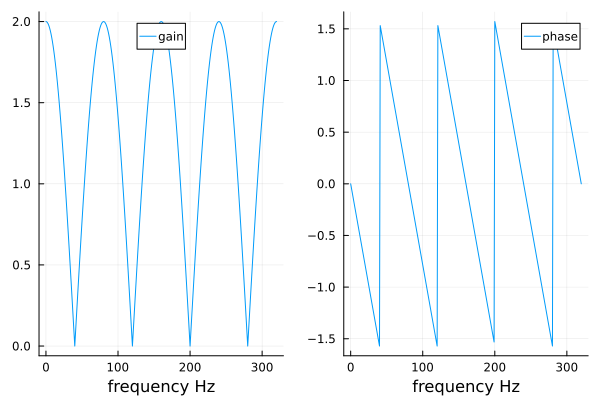

In [12]:
gainplot = plot(freq, rw, label="gain", legend=:top, xlabel="frequency Hz")
phaseplot = plot(freq, phi, label="phase", legend=:topright, xlabel="frequency Hz")
plot(gainplot,phaseplot)

From the gains, we see that signls at 40 Hz are removed, but also those around 120 Hz, 200 Hz, and 280 Hz.

# Question 3

A plywood manufacturer offers four types of plywood,
distinguished as grades $A$, $B$, $C$, 
and $D$, with revenues $\$25$, $\$12$, $\$9$, and $\$4$ respectively.

* Upper limits on production are 1000/3 for $A$ and $D$;
  and 1500/3 for $B$ and $C$.

* In 8 hours, a laborer can produce at most 1/25-th units
  of $A$ and $B$ and 1/30-th units of $C$ and $D$.
        
* The manufacturer needs to offer 40\% of grade $A$ and $B$,
  and 60\% of grade $C$ and $D$.

Formulate the optimization problem to maximize revenue,
subject to the constraints.

## answer to question 3

We use JuMP to formulate the model.

In [13]:
model = Model(GLPK.Optimizer)

@variable(model, xA >= 0)  # Grade A
@variable(model, xB >= 0)  # Grade B
@variable(model, xC >= 0)  # Grade C
@variable(model, xD >= 0)  # Grade D

@objective(model, Max, 25*xA + 12*xB + 9*xC + 4*xD)
print(model)

In [14]:
@constraint(model, xA <= 1000/3)  
@constraint(model, xB <= 1500/3)  
@constraint(model, xC <= 1500/3)
@constraint(model, xD <= 1000/3)
print(model)

The labor constraints are that total labor time must not exceed 8 hours.

In [15]:
@constraint(model, 25*xA + 25*xB + 30*xC + 30*xD <= 8)
print(model)

Then we have the percentages of the total production:
1. $x_A + x_B = 0.4(x_A + x_B + x_C + x_D)$
2. $x_C + x_D = 0.6(x_A + x_B + x_C + x_D)$

which simplifies into
1. $0.6(x_A + x_B) = 0.4(x_C + x_D)$
2. $0.4(x_C + x_D) = 0.6(x_A + x_B)$

In [16]:
@constraint(model, 0.6*(xA + xB) == 0.4*(xC + xD))
print(model)

In [17]:
optimize!(model)
solution_summary(model)

solution_summary(; result = 1, verbose = false)
├ solver_name          : GLPK
├ Termination
│ ├ termination_status : OPTIMAL
│ ├ result_count       : 1
│ ├ raw_status         : Solution is optimal
│ └ objective_bound    : Inf
├ Solution (result = 1)
│ ├ primal_status        : FEASIBLE_POINT
│ ├ dual_status          : FEASIBLE_POINT
│ ├ objective_value      : 4.40000e+00
│ └ dual_objective_value : 4.40000e+00
└ Work counters
  └ solve_time (sec)   : 1.20001e-02

The model has a feasible solution.

In [18]:
println("xA : ", value(xA))
println("xB : ", value(xB))
println("xC : ", value(xC))
println("xD : ", value(xD))

xA : 0.11428571428571427
xB : 0.0
xC : 0.1714285714285714
xD : 0.0


# Question 4

Choose between two payout plans for a sum of $p$ dollars:
    
1. either you receive 90\% of $p$ now; or

2. $p/12$ now, followed by 11 monthly installments of $p/12$.

What should the interest rate be to break even?  Justify your answer.

## answer to question 4

The equation we want to solve is

$$
   0.9 p = (p/12) \sum_{k=0}^{11} \exp(-k (r/12))
$$

where $r$ is the annual rate.

In [19]:
"""
function f!(F, x)
defines F[1] as the input to nlsolve.
"""
function f!(F, x)
    r = x[1]
    F[1] = 0.9 - (1/12)*sum(exp(-r*(k-1)/12) for k=1:12)
end

f!

In [20]:
sol = nlsolve(f!, [0.05])

Results of Nonlinear Solver Algorithm
 * Algorithm: Trust-region with dogleg and autoscaling
 * Starting Point: [0.05]
 * Zero: [0.2348546092689165]
 * Inf-norm of residuals: 0.000000
 * Iterations: 5
 * Convergence: true
   * |x - x'| < 0.0e+00: false
   * |f(x)| < 1.0e-08: true
 * Function Calls (f): 6
 * Jacobian Calls (df/dx): 6

The annual rate at which both options are the same is 23.49%.

In [21]:
0.2349/12

0.019575

The monthly rate is 1.96%.

# Question 5

Describe in one paragraph what you learned 
from *another* project presentation.